# Exploratory Data Analysis on Retail Sales Data
### OASIS INFOBYTE - Data Analytics Internship | Level 1, Task 1

**Author:** *(Minal Sadiq)*


**Track:** Data Analytics

---

**Roadmap**
1. Data Loading & Structural Inspection
2. Data Cleaning (documented)
3. Descriptive Statistics (mean, median, mode, variance, std, skewness, kurtosis, IQR)
4. Distribution Analysis & Normality Testing (Shapiro-Wilk, D'Agostino K², Q-Q plots)
5. Normalization / Standardization (Z-score, Min-Max, log-transform) + re-testing normality
6. Outlier Detection (IQR method)
7. Time Series Analysis (monthly & quarterly trends)
8. Customer Demographics + Hypothesis Testing (Levene's test, independent t-test, one-way ANOVA)
9. Product & Category Analysis + ANOVA across categories
10. Correlation & Multicollinearity (Pearson correlation, Variance Inflation Factor)
11. Independence Testing on Categorical Variables (Chi-Square Test of Independence)
12. Discount Behaviour - correlation test & ANOVA across discount tiers
13. Conclusion & Evidence-Based Business Recommendations


## 1. Setup & Data Loading

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import os

# Plot settings
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PALETTE = "crest"
ALPHA = 0.05

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Output folder
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load dataset
df = pd.read_csv(
    r"D:\Important Files\Internships\OASIS INFOBYTE\OASIS INFOBYTE (Data Analytics)\Level 1 , Task 1\Retail-Sales-EDA\dataset\retail_sales_dataset.csv"
)

print("Shape of dataset:", df.shape)

df.head()

Shape of dataset: (9825, 14)


,Order_ID,Order_Date,Customer_ID,Customer_Age,Customer_Gender,Region,Customer_Segment,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Net_Revenue,Payment_Mode
0,ORD100507,2024-08-02,CUST01862,33,Male,North,Premium,Furniture,Study Table,2,"8,712.060",0,"17,424.120",UPI/Wallet
1,ORD100011,2024-11-13,CUST00236,18,Female,North,Regular,Electronics,Webcam HD,4,"3,428.250",0,"13,713.000",Cash on Delivery
2,ORD102335,2024-02-09,CUST00307,27,Female,Central,Regular,Electronics,Wireless Mouse,2,"7,567.820",0,"15,135.640",UPI/Wallet
3,ORD103907,2024-09-26,CUST01484,39,Male,South,Regular,Furniture,Study Table,1,"5,215.860",15,"4,433.480",Debit Card
4,ORD106168,2023-01-22,CUST02596,18,Female,North,Regular,Clothing,Winter Jacket,2,"2,334.290",0,"4,668.580",Credit Card


### 1.1 Structural Inspection: shape, dtypes, nulls

In [36]:
print("SHAPE")
print(df.shape, "\n")

print("=" * 35)

print("COLUMN DATA TYPES")
print(df.dtypes, "\n")

print("=" * 35)

print("NULL VALUE COUNT PER COLUMN")
print(df.isnull().sum())

SHAPE
(9825, 14) 

COLUMN DATA TYPES
Order_ID             object
Order_Date           object
Customer_ID          object
Customer_Age          int64
Customer_Gender      object
Region               object
Customer_Segment     object
Product_Category     object
Product_Name         object
Quantity              int64
Unit_Price          float64
Discount_Percent      int64
Net_Revenue         float64
Payment_Mode         object
dtype: object 

NULL VALUE COUNT PER COLUMN
Order_ID              0
Order_Date            0
Customer_ID           0
Customer_Age          0
Customer_Gender       0
Region                0
Customer_Segment      0
Product_Category      0
Product_Name          0
Quantity              0
Unit_Price            0
Discount_Percent      0
Net_Revenue           0
Payment_Mode        125
dtype: int64


## 2. Data Cleaning (Documented)

In [37]:
before_rows = len(df)
before_dupes = df.duplicated().sum()

# Clean categorical data
df["Customer_Gender"] = df["Customer_Gender"].str.strip().str.capitalize()
df["Payment_Mode"] = df["Payment_Mode"].fillna("Unknown")

# Remove duplicates
df = df.drop_duplicates()

# Convert date and create date features
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Order_Month"] = df["Order_Date"].dt.month
df["Order_Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)
df["Order_YearMonth"] = df["Order_Date"].dt.to_period("M").astype(str)

# Create age groups
bins = [17, 25, 35, 45, 55, 71]
labels = ["18-25", "26-35", "36-45", "46-55", "56-70"]

df["Age_Group"] = pd.cut(df["Customer_Age"], bins=bins, labels=labels)

print(f"Rows before cleaning : {before_rows}")
print(f"Exact duplicates removed: {before_dupes}")
print(f"Rows after cleaning  : {len(df)}")
print("Gender categories now:", df["Customer_Gender"].unique())


Rows before cleaning : 9825
Exact duplicates removed: 25
Rows after cleaning  : 9800
Gender categories now: ['Male' 'Female']


## 3. Descriptive Statistics

In [38]:
numeric_cols = [
    "Customer_Age",
    "Quantity",
    "Unit_Price",
    "Discount_Percent",
    "Net_Revenue"
]

desc_stats = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "mode": df[numeric_cols].mode().iloc[0],
    "variance": df[numeric_cols].var(),
    "std_dev": df[numeric_cols].std(),
    "skewness": df[numeric_cols].apply(stats.skew),
    "kurtosis": df[numeric_cols].apply(stats.kurtosis),
    "min": df[numeric_cols].min(),
    "Q1": df[numeric_cols].quantile(0.25),
    "Q3": df[numeric_cols].quantile(0.75),
    "max": df[numeric_cols].max()
})

desc_stats["IQR"] = desc_stats["Q3"] - desc_stats["Q1"]

desc_stats.round(3)


,mean,median,mode,variance,std_dev,skewness,kurtosis,min,Q1,Q3,max,IQR
Customer_Age,34.515,34.000,18.000,105.985,10.295,0.330,-0.259,18.000,27.000,41.000,70.000,14.000
Quantity,1.631,1.000,1.000,0.886,0.941,1.670,2.452,1.000,1.000,2.000,5.000,1.000
Unit_Price,"5,559.299","3,150.095",391.990,"41,657,735.151","6,454.280",2.536,6.662,250.080,"1,847.072","6,872.092","34,984.110","5,025.020"
Discount_Percent,5.912,5.000,0.000,54.335,7.371,1.046,-0.006,0.000,0.000,10.000,25.000,10.000
Net_Revenue,"8,450.103","4,406.790",372.370,"148,715,969.581","12,194.916",4.469,30.244,206.810,"2,215.428","9,324.780","166,005.140","7,109.352"


In [39]:
print("Skewness interpretation (rule of thumb: |skew| < 0.5 ~ symmetric, 0.5-1 moderate, >1 highly skewed):")

for col in numeric_cols:
    sk = stats.skew(df[col])
    magnitude = (
        "highly skewed" if abs(sk) > 1
        else "moderately skewed" if abs(sk) > 0.5
        else "approximately symmetric"
    )
    direction = "right (positive)" if sk > 0 else "left (negative)"
    print(f"  {col:<18} skew = {sk:6.3f}  -> {magnitude}, tail to the {direction}")

Skewness interpretation (rule of thumb: |skew| < 0.5 ~ symmetric, 0.5-1 moderate, >1 highly skewed):
  Customer_Age       skew =  0.330  -> approximately symmetric, tail to the right (positive)
  Quantity           skew =  1.670  -> highly skewed, tail to the right (positive)
  Unit_Price         skew =  2.536  -> highly skewed, tail to the right (positive)
  Discount_Percent   skew =  1.046  -> highly skewed, tail to the right (positive)
  Net_Revenue        skew =  4.469  -> highly skewed, tail to the right (positive)


## 4. Distribution Analysis & Normality Testing

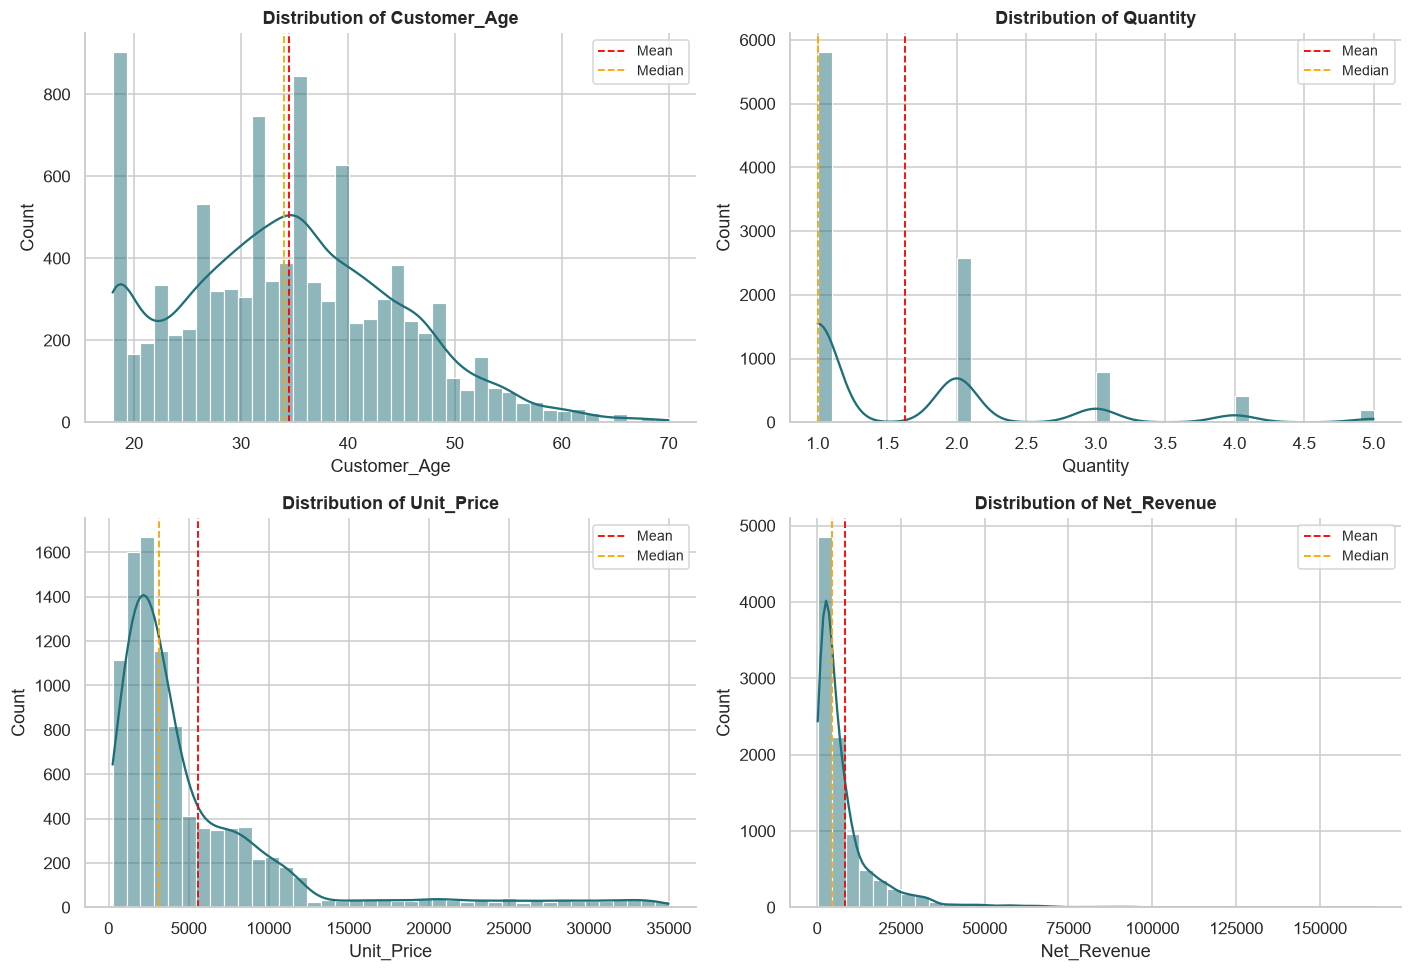

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

dist_cols = ["Customer_Age", "Quantity", "Unit_Price", "Net_Revenue"]

for ax, col in zip(axes.flat, dist_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#1f6f78", bins=40)
    ax.set_title(f"Distribution of {col}", fontweight="bold")
    ax.axvline(df[col].mean(), color="red", linestyle="--", linewidth=1.2, label="Mean")
    ax.axvline(df[col].median(), color="orange", linestyle="--", linewidth=1.2, label="Median")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_distributions_histkde.png", bbox_inches="tight")
plt.show()


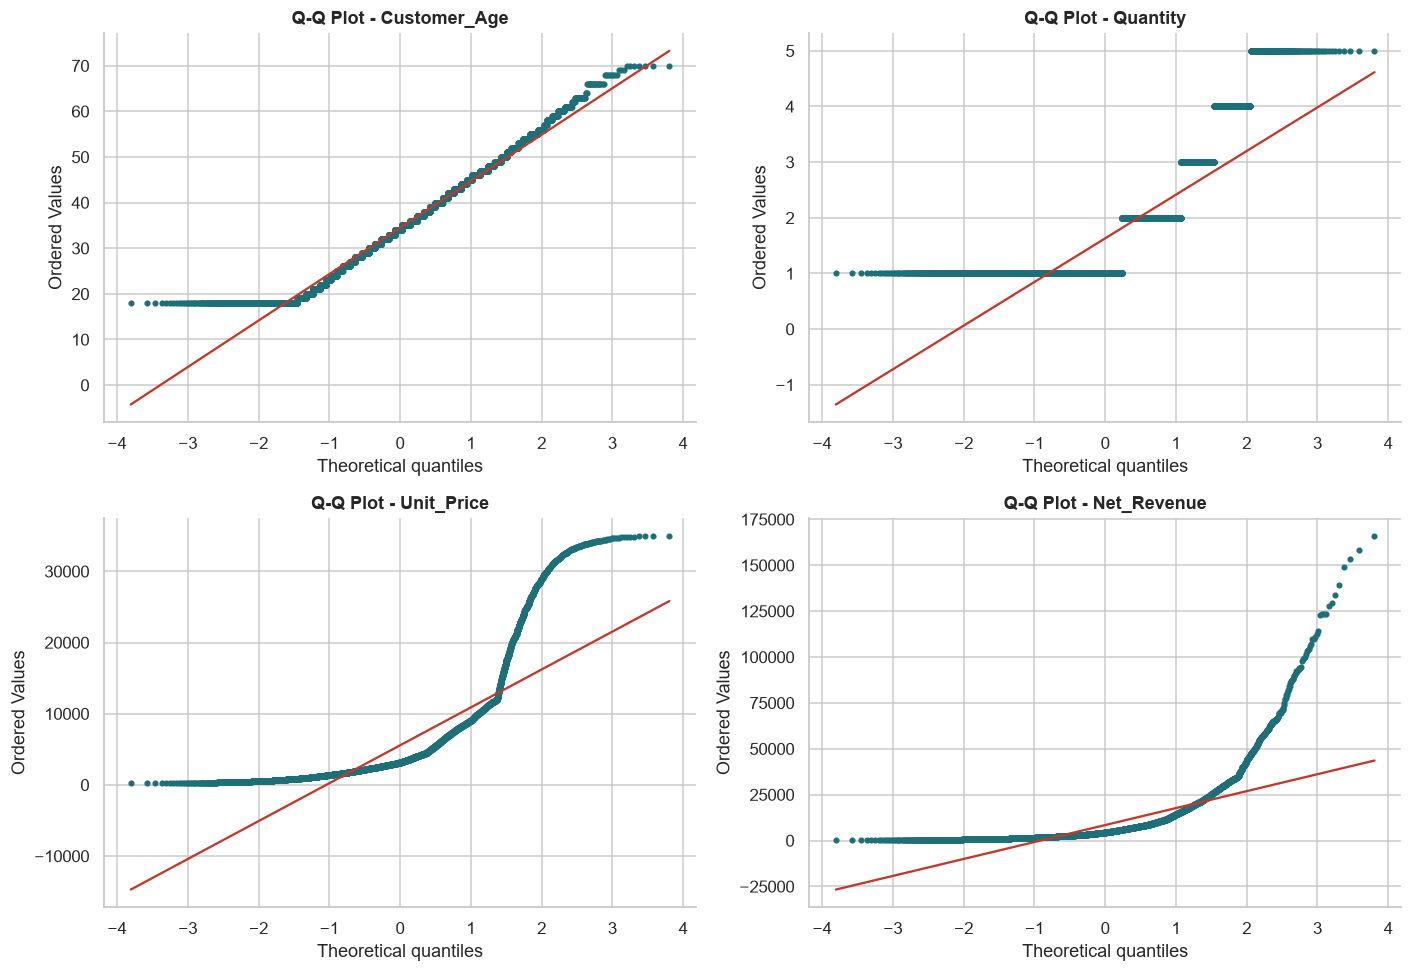

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(axes.flat, dist_cols):
    stats.probplot(df[col], dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot - {col}", fontweight="bold")
    
    ax.get_lines()[0].set(
        markerfacecolor="#1f6f78",
        markeredgecolor="#1f6f78",
        markersize=3
    )
    ax.get_lines()[1].set_color("#c0392b")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_qqplots.png", bbox_inches="tight")
plt.show()

In [44]:
print(f"{'Variable':<16}{'Shapiro-Wilk W':>16}{'p-value':>12}{'D-Agostino K2':>16}{'p-value':>12}   Conclusion (alpha=0.05)")
print("=" * 100)

rng = np.random.default_rng(42)

for col in dist_cols:
    data = df[col].dropna()
    sample = data if len(data) <= 5000 else pd.Series(
        rng.choice(data, 5000, replace=False)
    )

    w_stat, w_p = stats.shapiro(sample)
    k2_stat, k2_p = stats.normaltest(data)

    conclusion = (
        "Approximately Normal"
        if w_p > ALPHA and k2_p > ALPHA
        else "NOT Normal (reject H0)"
    )

    print(f"{col:<16}{w_stat:16.4f}{w_p:12.4g}{k2_stat:16.2f}{k2_p:12.4g}   {conclusion}")

Variable          Shapiro-Wilk W     p-value   D-Agostino K2     p-value   Conclusion (alpha=0.05)
Customer_Age              0.9775   1.944e-27          205.07   2.943e-45   NOT Normal (reject H0)
Quantity                  0.6928   5.733e-70         2906.95           0   NOT Normal (reject H0)
Unit_Price                0.6755   4.442e-71         5072.96           0   NOT Normal (reject H0)
Net_Revenue               0.5783   1.647e-76         9093.72           0   NOT Normal (reject H0)


## 5. Normalization / Standardization

In [45]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scale_cols = ["Customer_Age", "Unit_Price", "Net_Revenue"]

z_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

df_z = pd.DataFrame(
    z_scaler.fit_transform(df[scale_cols]),
    columns=[f"{c}_zscore" for c in scale_cols]
)

df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df[scale_cols]),
    columns=[f"{c}_minmax" for c in scale_cols]
)

print("Z-score standardised (mean should be ~0, std should be ~1):")
print(df_z.agg(["mean", "std"]).round(3), "\n")

print("=" * 65)

print("Min-Max normalised (min should be 0, max should be 1):")
print(df_minmax.agg(["min", "max"]).round(3))

Z-score standardised (mean should be ~0, std should be ~1):
      Customer_Age_zscore  Unit_Price_zscore  Net_Revenue_zscore
mean               -0.000              0.000               0.000
std                 1.000              1.000               1.000 

Min-Max normalised (min should be 0, max should be 1):
     Customer_Age_minmax  Unit_Price_minmax  Net_Revenue_minmax
min                0.000              0.000               0.000
max                1.000              1.000               1.000


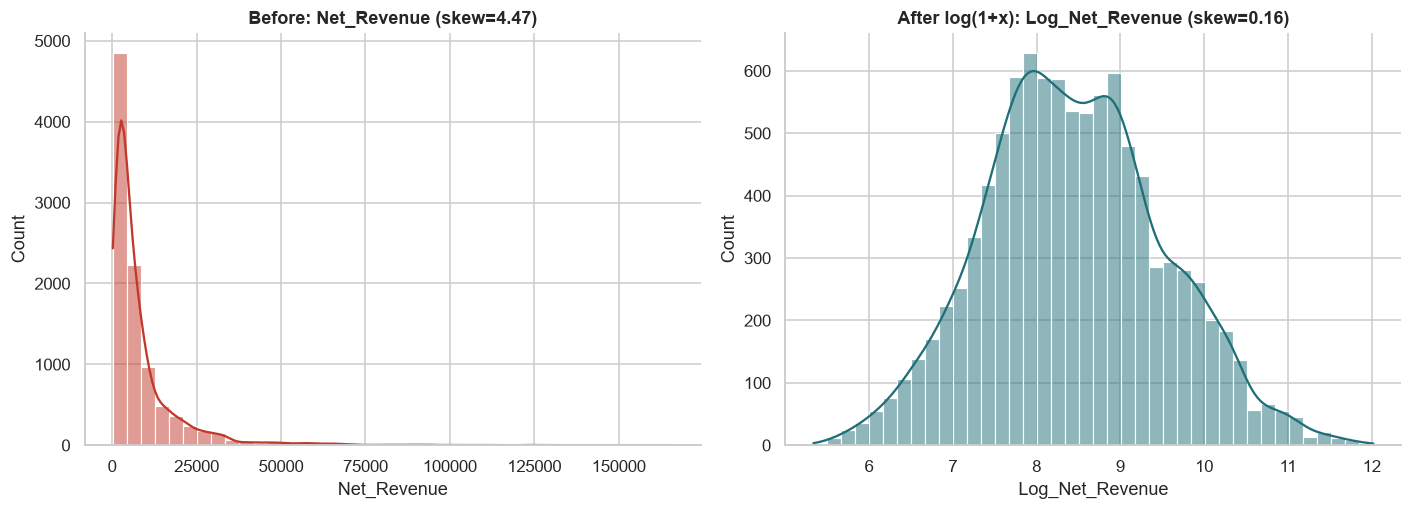

D'Agostino K2 test on Log_Net_Revenue: statistic=55.40, p-value=9.315e-13
Still not perfectly normal (p < 0.05), but skewness is substantially reduced -- log-revenue is used for the parametric group comparisons in Section 8.


In [46]:
# Log-transform revenue
df["Log_Net_Revenue"] = np.log1p(df["Net_Revenue"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.histplot(df["Net_Revenue"], kde=True, ax=axes[0], color="#c0392b", bins=40)
axes[0].set_title(
    f"Before: Net_Revenue (skew={stats.skew(df['Net_Revenue']):.2f})",
    fontweight="bold"
)

sns.histplot(df["Log_Net_Revenue"], kde=True, ax=axes[1], color="#1f6f78", bins=40)
axes[1].set_title(
    f"After log(1+x): Log_Net_Revenue (skew={stats.skew(df['Log_Net_Revenue']):.2f})",
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/10_log_transform_revenue.png", bbox_inches="tight")
plt.show()

k2_stat, k2_p = stats.normaltest(df["Log_Net_Revenue"])

print(f"D'Agostino K2 test on Log_Net_Revenue: statistic={k2_stat:.2f}, p-value={k2_p:.4g}")
print(
    "Still not perfectly normal (p < 0.05), but skewness is substantially reduced -- "
    "log-revenue is used for the parametric group comparisons in Section 8."
)

## 6. Outlier Detection (IQR Method)

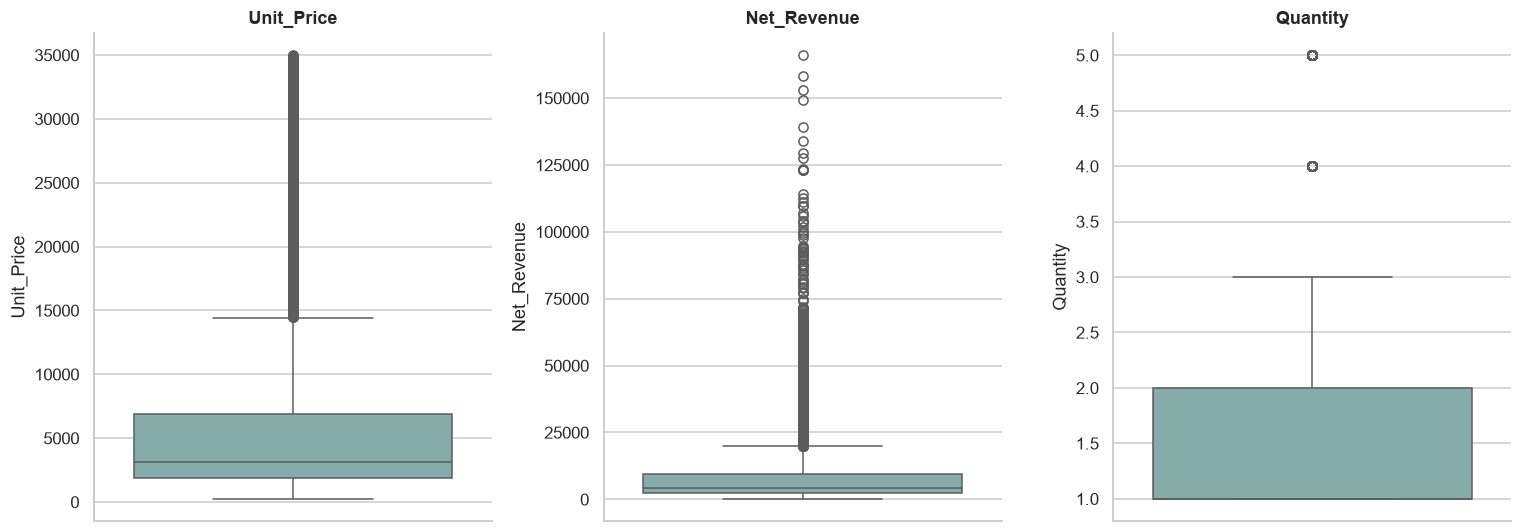

,lower_bound,upper_bound,n_outliers,pct_outliers
Unit_Price,"-5,690.457","14,409.622",758.000,7.730
Net_Revenue,"-8,448.601","19,988.809",982.000,10.020
Quantity,-0.500,3.500,605.000,6.170


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
outlier_report = {}

for ax, col in zip(axes, ["Unit_Price", "Net_Revenue", "Quantity"]):
    sns.boxplot(y=df[col], ax=ax, color="#7fb3b0")
    ax.set_title(col, fontweight="bold")

    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_report[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "n_outliers": n_out,
        "pct_outliers": round(100 * n_out / len(df), 2)
    }

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/11_outlier_boxplots.png", bbox_inches="tight")
plt.show()

pd.DataFrame(outlier_report).T

## 7. Time Series Analysis - Monthly & Quarterly Sales Trends

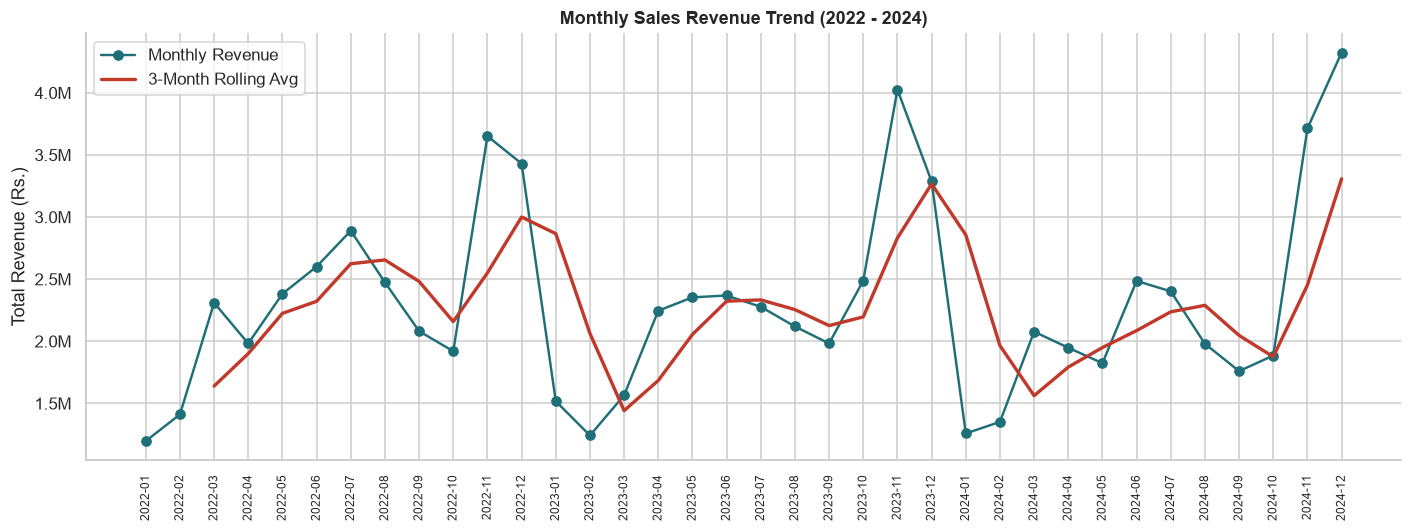

In [48]:
monthly = (
    df.groupby("Order_YearMonth", as_index=False)["Net_Revenue"]
      .sum()
      .sort_values("Order_YearMonth")
)

monthly["Rolling_3M_Avg"] = monthly["Net_Revenue"].rolling(3).mean()

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    monthly["Order_YearMonth"], monthly["Net_Revenue"],
    marker="o", color="#1f6f78", linewidth=1.6, label="Monthly Revenue"
)

ax.plot(
    monthly["Order_YearMonth"], monthly["Rolling_3M_Avg"],
    color="#c0392b", linewidth=2.2, label="3-Month Rolling Avg"
)

ax.set(
    title="Monthly Sales Revenue Trend (2022 - 2024)",
    ylabel="Total Revenue (Rs.)"
)

ax.title.set_fontweight("bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.xticks(rotation=90, fontsize=8)
ax.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_monthly_sales_trend.png", bbox_inches="tight")
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_11892\1968437683.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


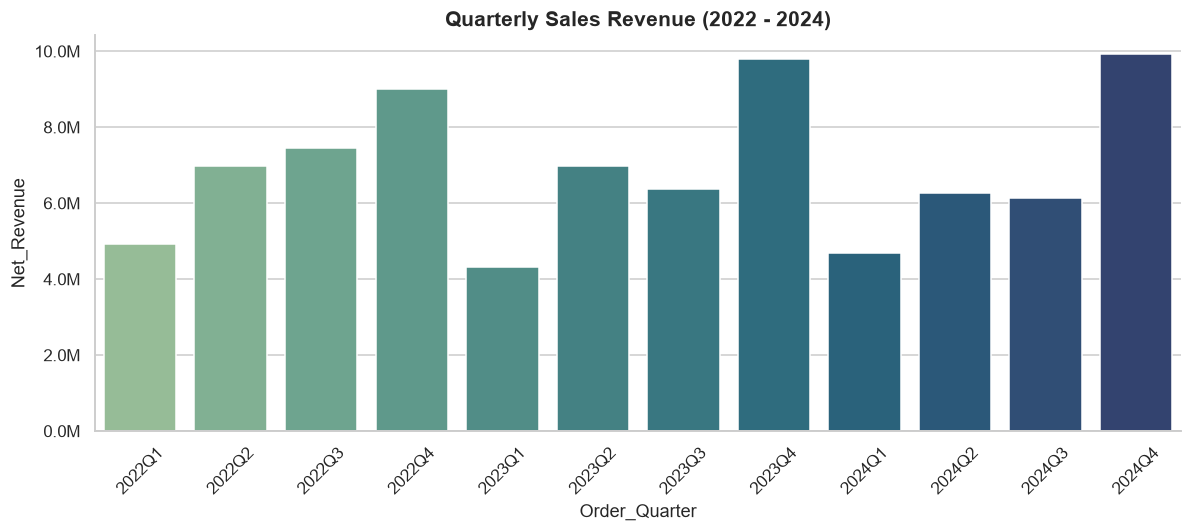

In [49]:

quarterly = (
    df.groupby("Order_Quarter", as_index=False)["Net_Revenue"]
      .sum()
      .sort_values("Order_Quarter")
)

fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=quarterly, x="Order_Quarter", y="Net_Revenue",
    palette=PALETTE, ax=ax
)

ax.set_title("Quarterly Sales Revenue (2022 - 2024)", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_quarterly_sales_trend.png", bbox_inches="tight")
plt.show()

## 8. Customer Demographics + Hypothesis Testing

C:\Users\User\AppData\Local\Temp\ipykernel_11892\1602065542.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, palette=PALETTE, ax=axes[0])


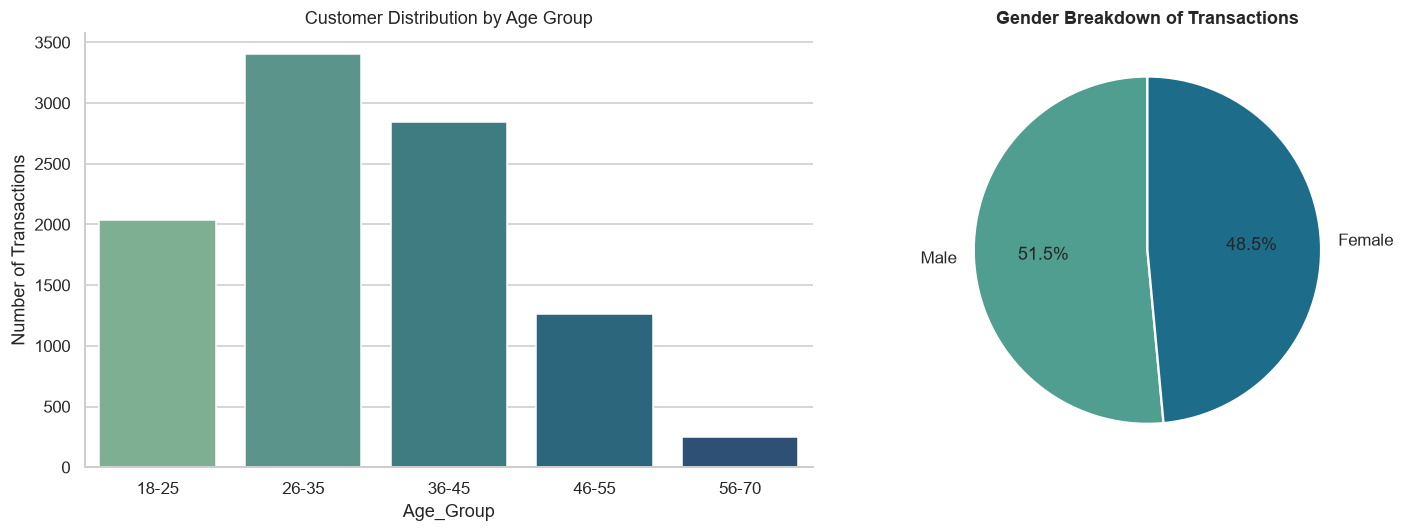

In [50]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_counts = df["Age_Group"].value_counts().sort_index()
sns.barplot(x=age_counts.index, y=age_counts.values, palette=PALETTE, ax=axes[0])
axes[0].set(title="Customer Distribution by Age Group", ylabel="Number of Transactions")

gender_counts = df["Customer_Gender"].value_counts()
axes[1].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette(PALETTE, len(gender_counts)),
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Gender Breakdown of Transactions", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_customer_demographics.png", bbox_inches="tight")
plt.show()

In [51]:
male_rev = df.loc[df["Customer_Gender"] == "Male", "Log_Net_Revenue"]
female_rev = df.loc[df["Customer_Gender"] == "Female", "Log_Net_Revenue"]

lev_stat, lev_p = stats.levene(male_rev, female_rev)
print(f"Levene's test for equal variances (Male vs Female): statistic={lev_stat:.3f}, p-value={lev_p:.4g}")

equal_var = lev_p > ALPHA
print(
    "-> Variances can be treated as equal."
    if equal_var
    else "-> Variances are significantly different; using Welch's t-test."
)

t_stat, t_p = stats.ttest_ind(male_rev, female_rev, equal_var=equal_var)

print("\nIndependent t-test (H0: mean log-revenue is equal for Male and Female):")
print(f"  t-statistic = {t_stat:.3f}, p-value = {t_p:.4g}")

if t_p < ALPHA:
    print(f"  -> p < {ALPHA}: reject H0. Mean order value genuinely differs by gender.")
else:
    print(
        f"  -> p >= {ALPHA}: fail to reject H0. No statistically significant difference "
        "in average order value between genders -- gender is NOT a useful revenue-targeting variable."
    )

Levene's test for equal variances (Male vs Female): statistic=0.344, p-value=0.5578
-> Variances can be treated as equal.

Independent t-test (H0: mean log-revenue is equal for Male and Female):
  t-statistic = -0.384, p-value = 0.7008
  -> p >= 0.05: fail to reject H0. No statistically significant difference in average order value between genders -- gender is NOT a useful revenue-targeting variable.


In [52]:
age_groups_data = [
    df.loc[df["Age_Group"] == g, "Log_Net_Revenue"].dropna()
    for g in labels
]

lev_stat, lev_p = stats.levene(*age_groups_data)
print(f"Levene's test across age groups: statistic={lev_stat:.3f}, p-value={lev_p:.4g}\n")

f_stat, anova_p = stats.f_oneway(*age_groups_data)
print("One-way ANOVA (H0: mean log-revenue is equal across all age groups):")
print(f"  F-statistic = {f_stat:.3f}, p-value = {anova_p:.4g}")

if anova_p < ALPHA:
    print(f"  -> p < {ALPHA}: reject H0. At least one age group has a significantly different average order value.")
else:
    print(f"  -> p >= {ALPHA}: fail to reject H0. Age group does not significantly affect average order value.")

revenue_by_age = df.groupby("Age_Group", observed=True)["Net_Revenue"].agg(["mean", "median", "count"])
revenue_by_age

Levene's test across age groups: statistic=0.643, p-value=0.6317

One-way ANOVA (H0: mean log-revenue is equal across all age groups):
  F-statistic = 1.078, p-value = 0.3654
  -> p >= 0.05: fail to reject H0. Age group does not significantly affect average order value.


,mean,median,count
Age_Group,,,
18-25,"8,697.046","4,400.610",2039
26-35,"8,693.063","4,607.490",3406
36-45,"8,112.655","4,379.080",2845
46-55,"8,225.239","4,239.500",1259
56-70,"8,099.919","3,683.140",251


## 9. Product & Category Analysis + ANOVA

C:\Users\User\AppData\Local\Temp\ipykernel_11892\2319787393.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


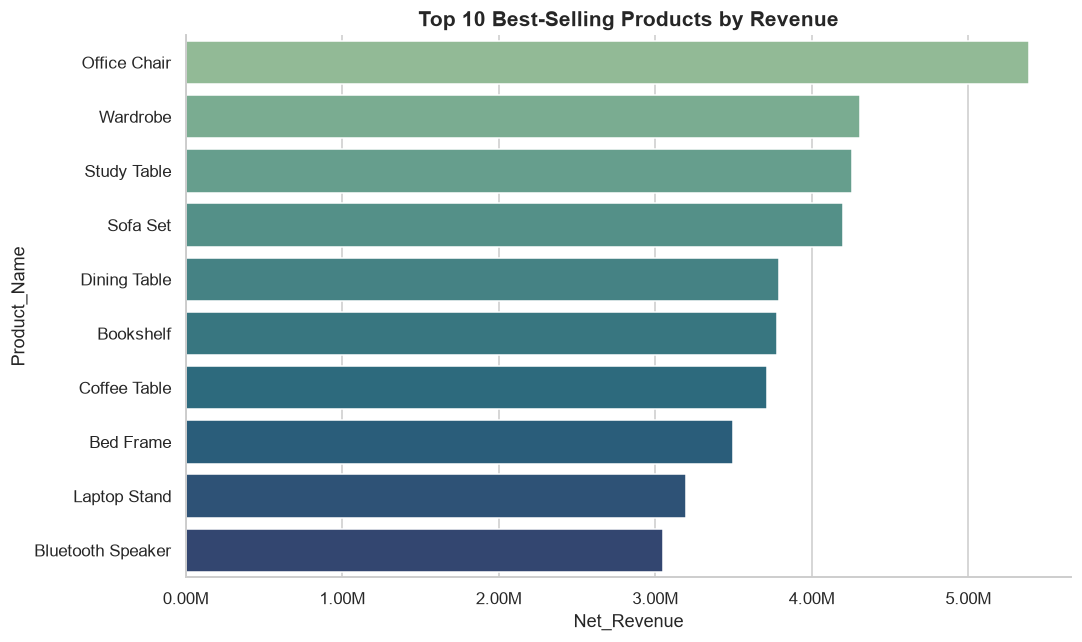

,Product_Name,Net_Revenue
0,Office Chair,"5,388,962.650"
1,Wardrobe,"4,306,308.150"
2,Study Table,"4,259,119.680"
3,Sofa Set,"4,197,497.990"
4,Dining Table,"3,792,115.190"
5,Bookshelf,"3,780,404.430"
6,Coffee Table,"3,710,758.270"
7,Bed Frame,"3,493,072.530"
8,Laptop Stand,"3,192,802.220"
9,Bluetooth Speaker,"3,045,789.420"


In [53]:
top_products = (
    df.groupby("Product_Name")["Net_Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_products,
    y="Product_Name",
    x="Net_Revenue",
    palette=PALETTE,
    ax=ax
)

ax.set_title("Top 10 Best-Selling Products by Revenue", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M"))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_top10_products.png", bbox_inches="tight")
plt.show()

top_products


C:\Users\User\AppData\Local\Temp\ipykernel_11892\65255071.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


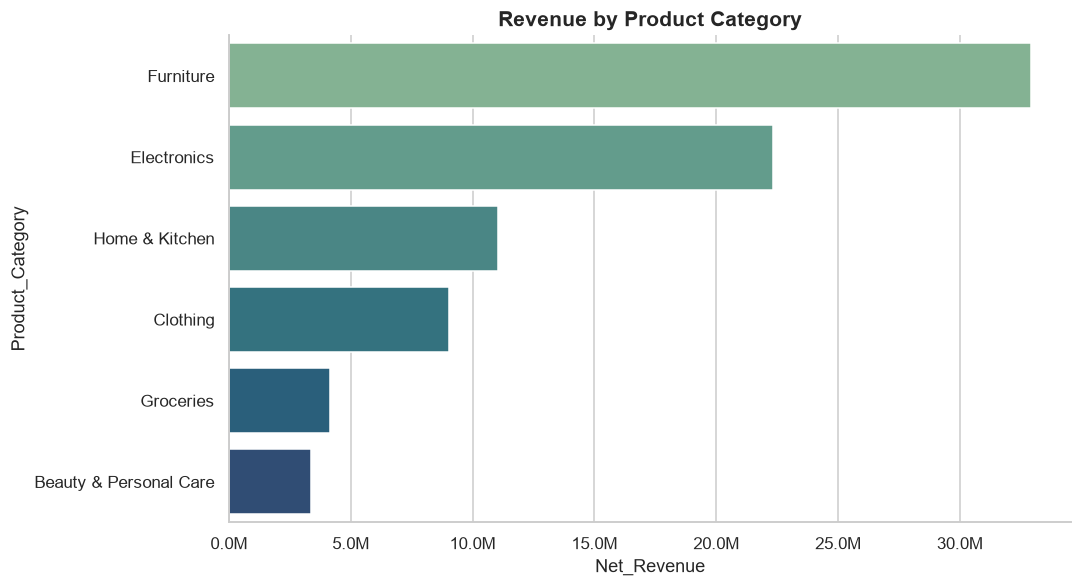

,Product_Category,Net_Revenue
0,Furniture,"32,928,238.890"
1,Electronics,"22,321,839.790"
2,Home & Kitchen,"11,040,505.960"
3,Clothing,"9,030,986.120"
4,Groceries,"4,133,134.700"
5,Beauty & Personal Care,"3,356,303.550"


In [54]:
category_revenue = (
    df.groupby("Product_Category")["Net_Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.barplot(
    data=category_revenue,
    x="Net_Revenue",
    y="Product_Category",
    palette=PALETTE,
    ax=ax
)

ax.set_title("Revenue by Product Category", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_category_revenue.png", bbox_inches="tight")
plt.show()

category_revenue

In [55]:
cat_groups = [g["Log_Net_Revenue"].values for _, g in df.groupby("Product_Category")]

f_stat, anova_p = stats.f_oneway(*cat_groups)

print("One-way ANOVA across Product_Category (H0: mean log-revenue per order is equal across categories):")
print(f"  F-statistic = {f_stat:.3f}, p-value = {anova_p:.4g}")
print(
    f"  -> {'Reject H0 -- categories differ significantly in average order value.' if anova_p < ALPHA else 'Fail to reject H0.'}"
)

One-way ANOVA across Product_Category (H0: mean log-revenue per order is equal across categories):
  F-statistic = 2025.239, p-value = 0
  -> Reject H0 -- categories differ significantly in average order value.


## 10. Correlation & Multicollinearity

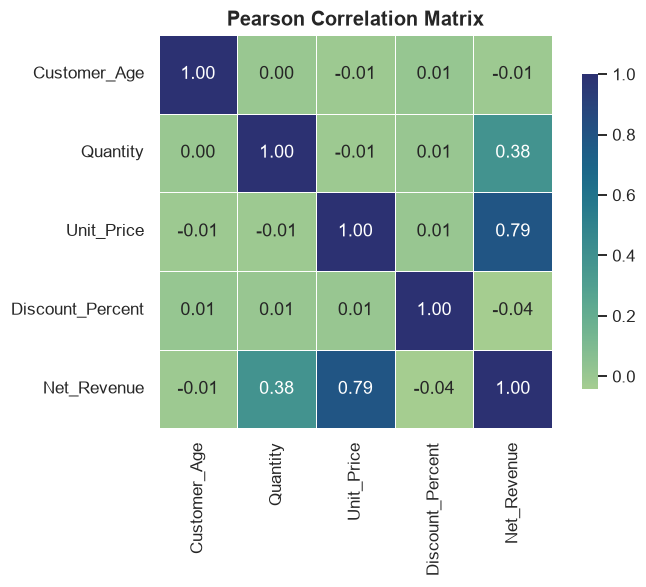

In [56]:
corr_cols = ["Customer_Age", "Quantity", "Unit_Price", "Discount_Percent", "Net_Revenue"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))

sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="crest", square=True,
    cbar_kws={"shrink": 0.8}, linewidths=0.5, ax=ax
)

ax.set_title("Pearson Correlation Matrix", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_correlation_heatmap.png", bbox_inches="tight")
plt.show()


In [57]:
vif_features = ["Customer_Age", "Quantity", "Unit_Price", "Discount_Percent"]
X = add_constant(df[vif_features])

vif_data = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_data = vif_data.query("Feature != 'const'").reset_index(drop=True)

vif_data["Flag"] = vif_data["VIF"].apply(
    lambda v: "OK" if v < 5 else "Moderate concern" if v < 10 else "Severe multicollinearity"
)

vif_data

,Feature,VIF,Flag
0,Customer_Age,1.000,OK
1,Quantity,1.000,OK
2,Unit_Price,1.000,OK
3,Discount_Percent,1.000,OK


## 11. Independence Testing on Categorical Variables (Chi-Square)

In [58]:
def chi_square_report(col1, col2):
    contingency = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)

    n = contingency.to_numpy().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

    verdict = "significant association (reject H0)" if p < ALPHA else "no significant association"

    print(f"{col1}  vs  {col2}")
    print(f"  Chi2 = {chi2:.2f}, dof = {dof}, p-value = {p:.4g}, Cramer's V = {cramers_v:.3f}  -> {verdict}\n")

    return contingency


pairs = [
    ("Customer_Gender", "Product_Category"),
    ("Region", "Payment_Mode"),
    ("Customer_Segment", "Product_Category")
]

for c1, c2 in pairs:
    chi_square_report(c1, c2)


Customer_Gender  vs  Product_Category
  Chi2 = 5.36, dof = 5, p-value = 0.3735, Cramer's V = 0.023  -> no significant association

Region  vs  Payment_Mode
  Chi2 = 20.90, dof = 20, p-value = 0.4033, Cramer's V = 0.023  -> no significant association

Customer_Segment  vs  Product_Category
  Chi2 = 28.13, dof = 10, p-value = 0.001718, Cramer's V = 0.038  -> significant association (reject H0)



## 12. Discount Behaviour - Correlation Test & ANOVA

In [59]:
r_stat, r_p = stats.pearsonr(df["Discount_Percent"], df["Quantity"])

print(f"Pearson correlation -- Discount_Percent vs Quantity: r = {r_stat:.3f}, p-value = {r_p:.4g}")

significance = "Statistically significant" if r_p < ALPHA else "Not statistically significant"
effect = (
    "negligible" if abs(r_stat) < 0.1
    else "weak" if abs(r_stat) < 0.3
    else "moderate"
)

print(f"  -> {significance} relationship, but r = {r_stat:.3f} indicates a {effect} practical effect.\n")

discount_bins = pd.cut(
    df["Discount_Percent"],
    bins=[-1, 0, 10, 100],
    labels=["No Discount", "5-10%", "15%+"]
)

groups = [
    df.loc[discount_bins == g, "Log_Net_Revenue"].dropna()
    for g in discount_bins.cat.categories
]

f_stat, anova_p = stats.f_oneway(*groups)

print(f"One-way ANOVA -- Log_Net_Revenue across discount tiers: F = {f_stat:.3f}, p-value = {anova_p:.4g}")

Pearson correlation -- Discount_Percent vs Quantity: r = 0.009, p-value = 0.3582
  -> Not statistically significant relationship, but r = 0.009 indicates a negligible practical effect.

One-way ANOVA -- Log_Net_Revenue across discount tiers: F = 22.575, p-value = 1.653e-10


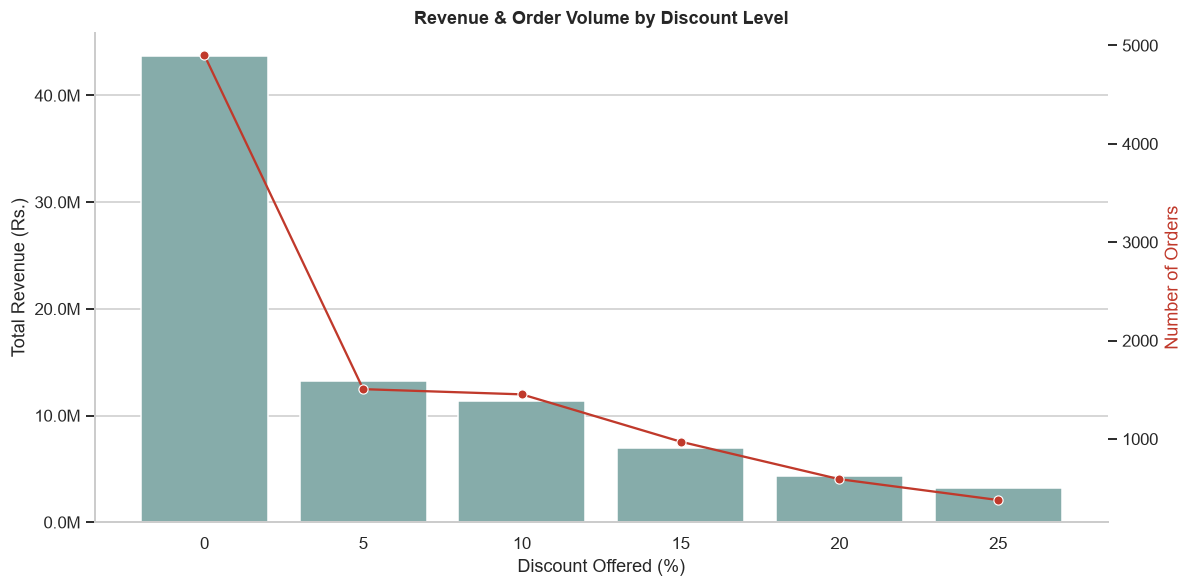

,Discount_Percent,Avg_Order_Value,Total_Revenue,Orders
0,0,"8,910.771","43,653,866.500",4899
1,5,"8,772.036","13,210,686.470",1506
2,10,"7,834.836","11,384,016.240",1453
3,15,"7,205.866","7,004,101.980",972
4,20,"7,364.030","4,352,141.630",591
5,25,"8,459.621","3,206,196.190",379


In [60]:
discount_summary = (
    df.groupby("Discount_Percent")
      .agg(
          Avg_Order_Value=("Net_Revenue", "mean"),
          Total_Revenue=("Net_Revenue", "sum"),
          Orders=("Order_ID", "count")
      )
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(11, 5.5))

sns.barplot(
    data=discount_summary, x="Discount_Percent", y="Total_Revenue",
    color="#7fb3b0", ax=ax1
)

ax1.set(
    xlabel="Discount Offered (%)",
    ylabel="Total Revenue (Rs.)",
    title="Revenue & Order Volume by Discount Level"
)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

ax2 = ax1.twinx()
sns.lineplot(
    data=discount_summary, x=discount_summary.index, y="Orders",
    marker="o", color="#c0392b", ax=ax2
)
ax2.set_ylabel("Number of Orders", color="#c0392b")
ax2.grid(False)

ax1.title.set_fontweight("bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_discount_vs_revenue.png", bbox_inches="tight")
plt.show()

discount_summary


## 13. Conclusion & Evidence-Based Business Recommendations

**Statistical Findings**
1. None of the core numeric variables (age, price, revenue, quantity) are normally distributed (Shapiro-Wilk & D'Agostino tests, all p < 0.05) revenue is right-skewed, so median/IQR were reported alongside the mean throughout, and a log-transform was used before parametric testing.
2. All four transaction-level predictors have VIF ≈ 1 **no multicollinearity concern** for future modelling.
3. Chi-square tests show the categorical fields in this dataset are essentially independent of each other (low Cramer's V) no hidden confound between e.g. gender and product category.
4. ANOVA confirms **Product_Category** has a statistically significant effect on order value, while the discount-tier ANOVA and the weak Discount-Quantity correlation together show discounting is a **weak lever for revenue**, not a strong one.

**Business Findings**
1. Sales are strongly seasonal a sharp Q4 (Oct-Dec) spike every year, a smaller Jun-Jul lift, and a consistently weak Q1.
2. The 26-45 age group carries the most transaction volume and hence the largest total revenue base.
3. Electronics and Furniture drive disproportionate revenue via high order value; Clothing drives volume at a lower price point.

---
*Report prepared as part of the OASIS INFOBYTE Data Analytics Internship - Task 1: EDA on Retail Sales Data.*
